<a href="https://colab.research.google.com/github/Jay4l44/Elevvo-Pathways-Internship/blob/Task-3/Task_3_Covertype_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Covertype Classification

## Libraries Used

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings for better visualization
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')  # or 'ggplot', 'fivethirtyeight'

print("All libraries downloaded successfully!")

All libraries downloaded successfully!


## Dataset

### Import dataset

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"

# Load the dataset
try:
    df = pd.read_csv(url, compression='gzip', header=None)
    print("Dataset loaded successfully from UCI Repository!\n")
except:
    print("Could not load from URL.\n")

Dataset loaded successfully from UCI Repository!



### Add columns to the dataset

In [ ]:
column_names = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
    'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points'
]

# Add Wilderness Area columns (4 binary columns)
for i in range(1, 5):
    column_names.append(f'Wilderness_Area_{i}')

# Add Soil Type columns (40 binary columns)
for i in range(1, 41):
    column_names.append(f'Soil_Type_{i}')

# Add target column
column_names.append('Cover_Type')

# Assign column names
df.columns = column_names

print("Column names assigned successfully!\n")

Column names assigned successfully!



### Load dataset

DATASET OVERVIEW

Dataset Shape: (581012, 55)
   - Rows (samples): 581,012
   - Columns (features): 55

First 5 rows of the dataset:
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0   

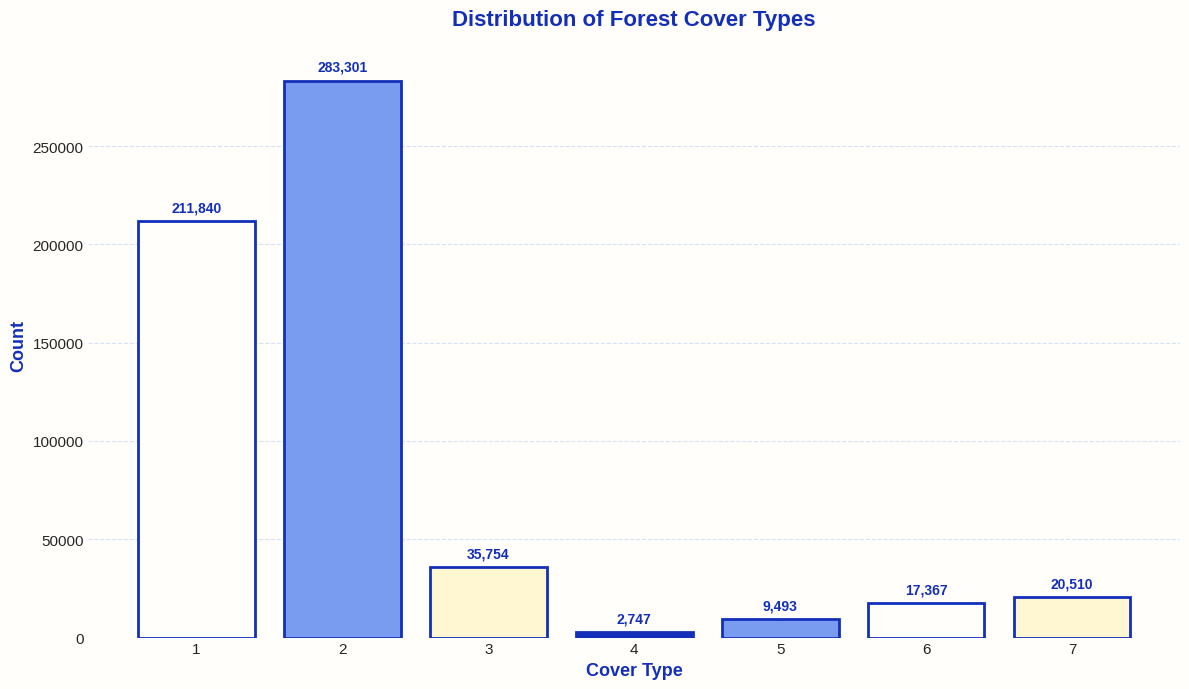

In [ ]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nDataset Shape: {df.shape}")
print(f"   - Rows (samples): {df.shape[0]:,}")
print(f"   - Columns (features): {df.shape[1]}\n")

print("First 5 rows of the dataset:")
print(df.head())

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes.value_counts())

print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing_values = df.isnull().sum().sum()
print(f"Total missing values: {missing_values}")
if missing_values == 0:
    print("No missing values found!")

print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
print(df.info())

print("\n" + "=" * 60)
print("TARGET VARIABLE: COVER TYPE")
print("=" * 60)

print("\nCover Type Distribution:")
print(df['Cover_Type'].value_counts().sort_index())

print("\nCover Type Percentages:")
print(df['Cover_Type'].value_counts(normalize=True).sort_index() * 100)

plt.figure(figsize=(12, 7))
cover_counts = df['Cover_Type'].value_counts().sort_index()

# Custom color palette
colors = ['#FFFEFA', '#799CF0', '#FFF6D2', '#132FBA', '#799CF0', '#FFFEFA', '#FFF6D2']

plt.bar(cover_counts.index, cover_counts.values, color=colors, edgecolor='#132FBA', linewidth=2)
plt.xlabel('Cover Type', fontsize=13, fontweight='bold', color='#132FBA')
plt.ylabel('Count', fontsize=13, fontweight='bold', color='#132FBA')
plt.title('Distribution of Forest Cover Types', fontsize=16, fontweight='bold', color='#132FBA', pad=20)
plt.xticks(range(1, 8), fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--', color='#799CF0')

# Add count labels on bars
for i, v in enumerate(cover_counts.values):
    plt.text(i + 1, v + 5000, f'{v:,}', ha='center', fontsize=10, fontweight='bold', color='#132FBA')

# Set background color
ax = plt.gca()
ax.set_facecolor('#FFFEFA')
plt.gcf().patch.set_facecolor('#FFFEFA')

plt.tight_layout()
plt.savefig('cover_type_distribution.png', dpi=300, bbox_inches='tight', facecolor='#FFFEFA')
plt.show()

### Examine target variable distribution

 Cover Type  Count  Percentage  Proportion
          1 211840       36.46      0.3646
          2 283301       48.76      0.4876
          3  35754        6.15      0.0615
          4   2747        0.47      0.0047
          5   9493        1.63      0.0163
          6  17367        2.99      0.0299
          7  20510        3.53      0.0353

Total Samples: 581,012
Number of Classes: 7

CLASS BALANCE ANALYSIS

Most Common Class: Cover Type 2 (283,301 samples, 48.76%)
Least Common Class: Cover Type 4 (2,747 samples, 0.47%)
Imbalance Ratio: 103.13:1

MODERATE CLASS IMBALANCE DETECTED!
   Consider using stratified sampling and class weights during training.

FOREST COVER TYPE DESCRIPTIONS


  1. Spruce/Fir           - 211,840 samples (36.46%)
  2. Lodgepole Pine       - 283,301 samples (48.76%)
  3. Ponderosa Pine       - 35,754 samples ( 6.15%)
  4. Cottonwood/Willow    -  2,747 samples ( 0.47%)
  5. Aspen                -  9,493 samples ( 1.63%)
  6. Douglas-fir          - 17,367 sample

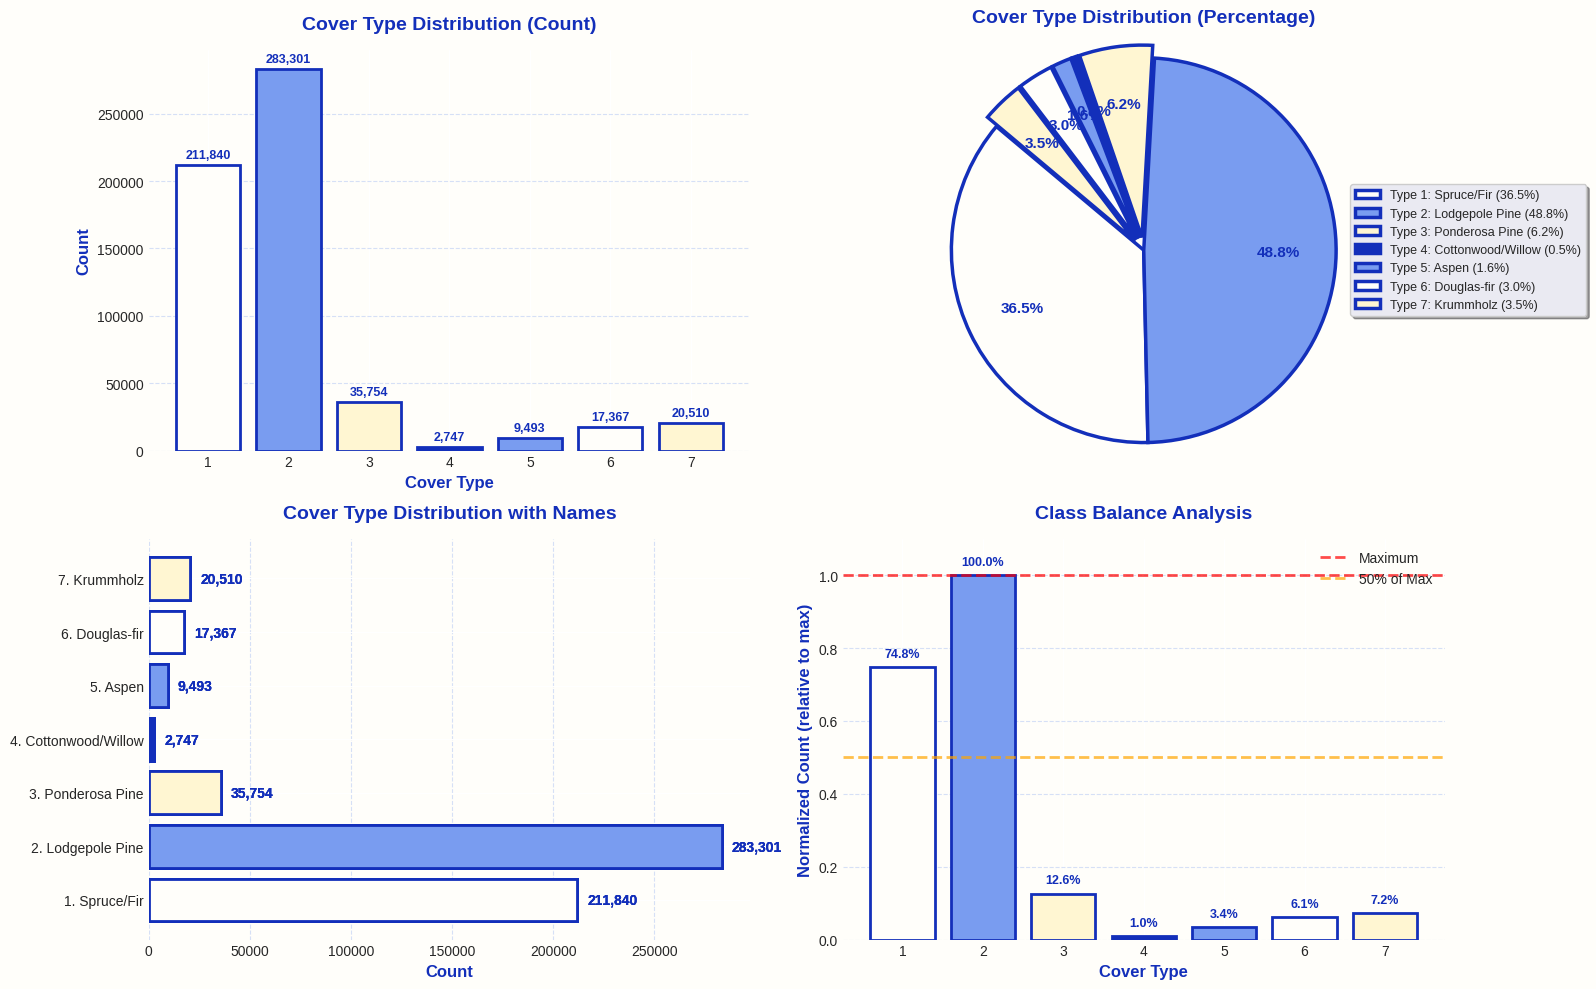

In [ ]:
colors = ['#FFFEFA', '#799CF0', '#FFF6D2', '#132FBA', '#799CF0', '#FFFEFA', '#FFF6D2']
primary_color = '#132FBA'
secondary_color = '#799CF0'
bg_color = '#FFFEFA'

cover_counts = df['Cover_Type'].value_counts().sort_index()
cover_percentages = df['Cover_Type'].value_counts(normalize=True).sort_index() * 100

stats_df = pd.DataFrame({
    'Cover Type': range(1, 8),
    'Count': cover_counts.values,
    'Percentage': cover_percentages.values.round(2),
    'Proportion': (cover_percentages.values / 100).round(4)
})

print(stats_df.to_string(index=False))

print(f"\nTotal Samples: {len(df):,}")
print(f"Number of Classes: {df['Cover_Type'].nunique()}")

print("\n" + "=" * 70)
print("CLASS BALANCE ANALYSIS")
print("=" * 70)

max_class = cover_counts.idxmax()
min_class = cover_counts.idxmin()
max_count = cover_counts.max()
min_count = cover_counts.min()
imbalance_ratio = max_count / min_count

print(f"\nMost Common Class: Cover Type {max_class} ({max_count:,} samples, {cover_percentages[max_class]:.2f}%)")
print(f"Least Common Class: Cover Type {min_class} ({min_count:,} samples, {cover_percentages[min_class]:.2f}%)")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 3:
    print("\nMODERATE CLASS IMBALANCE DETECTED!")
    print("   Consider using stratified sampling and class weights during training.")
elif imbalance_ratio > 1.5:
    print("\nSLIGHT CLASS IMBALANCE (acceptable range)")
else:
    print("\nWELL-BALANCED DATASET")

print("\n" + "=" * 70)
print("FOREST COVER TYPE DESCRIPTIONS")
print("=" * 70)

cover_descriptions = {
    1: "Spruce/Fir",
    2: "Lodgepole Pine",
    3: "Ponderosa Pine",
    4: "Cottonwood/Willow",
    5: "Aspen",
    6: "Douglas-fir",
    7: "Krummholz"
}

print("\n")
for cover_type, description in cover_descriptions.items():
    count = cover_counts[cover_type]
    pct = cover_percentages[cover_type]
    print(f"  {cover_type}. {description:20s} - {count:6,} samples ({pct:5.2f}%)")

# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(bg_color)

# Subplot 1: Bar Chart
ax1 = plt.subplot(2, 2, 1)
bars = ax1.bar(cover_counts.index, cover_counts.values, color=colors,
               edgecolor=primary_color, linewidth=2)
ax1.set_xlabel('Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax1.set_ylabel('Count', fontsize=12, fontweight='bold', color=primary_color)
ax1.set_title('Cover Type Distribution (Count)', fontsize=14, fontweight='bold',
              color=primary_color, pad=15)
ax1.set_xticks(range(1, 8))
ax1.grid(axis='y', alpha=0.3, linestyle='--', color=secondary_color)
ax1.set_facecolor(bg_color)

# Add count labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 3000,
             f'{int(height):,}', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color=primary_color)

# Subplot 2: Pie Chart
ax2 = plt.subplot(2, 2, 2)
wedges, texts, autotexts = ax2.pie(cover_percentages.values,
                                     autopct='%1.1f%%', startangle=140,
                                     colors=colors,
                                     wedgeprops={'edgecolor': primary_color, 'linewidth': 2.5},
                                     pctdistance=0.70,
                                     explode=[0, 0, 0.08, 0.08, 0.08, 0.08, 0.08],
                                     radius=1.2)  # Make pie chart BIGGER
ax2.set_title('Cover Type Distribution (Percentage)', fontsize=14, fontweight='bold',
              color=primary_color, pad=20)

# Style the percentage text - ALL IN DARK BLUE, BIGGER FONT
for autotext in autotexts:
    autotext.set_color(primary_color)  # Dark blue (#132FBA)
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

# Create a clean legend instead of labels
legend_labels = [f'Type {i}: {cover_descriptions[i]} ({cover_percentages[i]:.1f}%)' for i in range(1, 8)]
ax2.legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=9, frameon=True, fancybox=True, shadow=True)

# Subplot 3: Horizontal Bar Chart with Labels
ax3 = plt.subplot(2, 2, 3)
y_pos = np.arange(len(cover_descriptions))
bars = ax3.barh(y_pos, cover_counts.values, color=colors,
                edgecolor=primary_color, linewidth=2)
ax3.set_yticks(y_pos)
ax3.set_yticklabels([f"{i}. {cover_descriptions[i]}" for i in range(1, 8)])
ax3.set_xlabel('Count', fontsize=12, fontweight='bold', color=primary_color)
ax3.set_title('Cover Type Distribution with Names', fontsize=14, fontweight='bold',
              color=primary_color, pad=15)
ax3.grid(axis='x', alpha=0.3, linestyle='--', color=secondary_color)
ax3.set_facecolor(bg_color)

# Add count labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 5000, bar.get_y() + bar.get_height()/2.,
             f'{int(width):,}', ha='left', va='center',
             fontsize=10, fontweight='bold', color=primary_color)
# Subplot 3: Horizontal Bar Chart with Labels
ax3 = plt.subplot(2, 2, 3)
y_pos = np.arange(len(cover_descriptions))
bars = ax3.barh(y_pos, cover_counts.values, color=colors,
                edgecolor=primary_color, linewidth=2)
ax3.set_yticks(y_pos)
ax3.set_yticklabels([f"{i}. {cover_descriptions[i]}" for i in range(1, 8)])
ax3.set_xlabel('Count', fontsize=12, fontweight='bold', color=primary_color)
ax3.set_title('Cover Type Distribution with Names', fontsize=14, fontweight='bold',
              color=primary_color, pad=15)
ax3.grid(axis='x', alpha=0.3, linestyle='--', color=secondary_color)
ax3.set_facecolor(bg_color)

# Add count labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 5000, bar.get_y() + bar.get_height()/2.,
             f'{int(width):,}', ha='left', va='center',
             fontsize=10, fontweight='bold', color=primary_color)

# Subplot 3: Horizontal Bar Chart with Labels
ax3 = plt.subplot(2, 2, 3)
y_pos = np.arange(len(cover_descriptions))
bars = ax3.barh(y_pos, cover_counts.values, color=colors,
                edgecolor=primary_color, linewidth=2)
ax3.set_yticks(y_pos)
ax3.set_yticklabels([f"{i}. {cover_descriptions[i]}" for i in range(1, 8)])
ax3.set_xlabel('Count', fontsize=12, fontweight='bold', color=primary_color)
ax3.set_title('Cover Type Distribution with Names', fontsize=14, fontweight='bold',
              color=primary_color, pad=15)
ax3.grid(axis='x', alpha=0.3, linestyle='--', color=secondary_color)
ax3.set_facecolor(bg_color)

# Add count labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 5000, bar.get_y() + bar.get_height()/2.,
             f'{int(width):,}', ha='left', va='center',
             fontsize=10, fontweight='bold', color=primary_color)

# Subplot 4: Imbalance Visualization
ax4 = plt.subplot(2, 2, 4)
normalized_counts = cover_counts.values / cover_counts.max()
bars = ax4.bar(cover_counts.index, normalized_counts, color=colors,
               edgecolor=primary_color, linewidth=2)
ax4.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Maximum', alpha=0.7)
ax4.axhline(y=0.5, color='orange', linestyle='--', linewidth=2, label='50% of Max', alpha=0.7)
ax4.set_xlabel('Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax4.set_ylabel('Normalized Count (relative to max)', fontsize=12, fontweight='bold', color=primary_color)
ax4.set_title('Class Balance Analysis', fontsize=14, fontweight='bold',
              color=primary_color, pad=15)
ax4.set_xticks(range(1, 8))
ax4.set_ylim([0, 1.1])
ax4.legend(loc='upper right', framealpha=0.9)
ax4.grid(axis='y', alpha=0.3, linestyle='--', color=secondary_color)
ax4.set_facecolor(bg_color)

# Add percentage labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height*100:.1f}%', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color=primary_color)

plt.tight_layout()
plt.savefig('target_distribution_analysis.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()


### Feature coorelation analysis


IDENTIFYING FEATURE TYPES

Total Features: 54
  Numerical Features: 10
  Categorical Features: 44
      - Wilderness Areas: 4
      - Soil Types: 40

Numerical Features:
    1. Elevation
    2. Aspect
    3. Slope
    4. Horizontal_Distance_To_Hydrology
    5. Vertical_Distance_To_Hydrology
    6. Horizontal_Distance_To_Roadways
    7. Hillshade_9am
    8. Hillshade_Noon
    9. Hillshade_3pm
   10. Horizontal_Distance_To_Fire_Points

Categorical Features (Binary One-Hot Encoded):
   - Wilderness_Area_1 to Wilderness_Area_4
   - Soil_Type_1 to Soil_Type_40

NUMERICAL FEATURES - DESCRIPTIVE STATISTICS

                                        count     mean      std     min  \
Elevation                           581012.0  2959.37   279.98  1859.0   
Aspect                              581012.0   155.66   111.91     0.0   
Slope                               581012.0    14.10     7.49     0.0   
Horizontal_Distance_To_Hydrology    581012.0   269.43   212.55     0.0   
Vertical_Distance_To

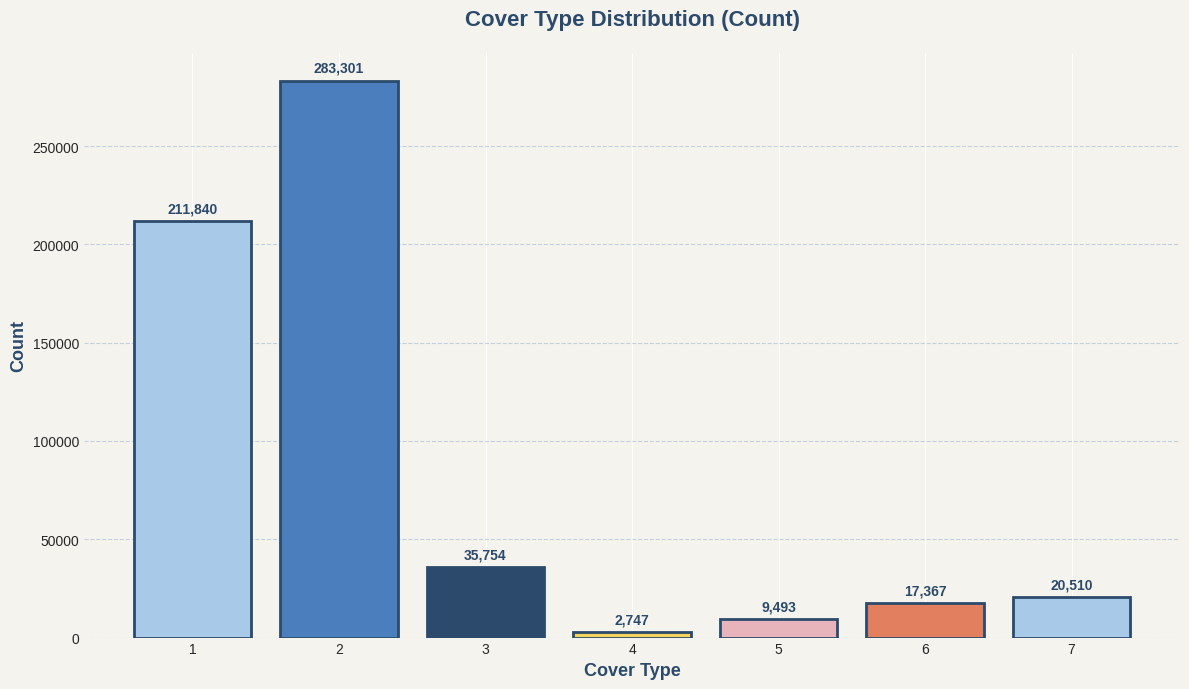

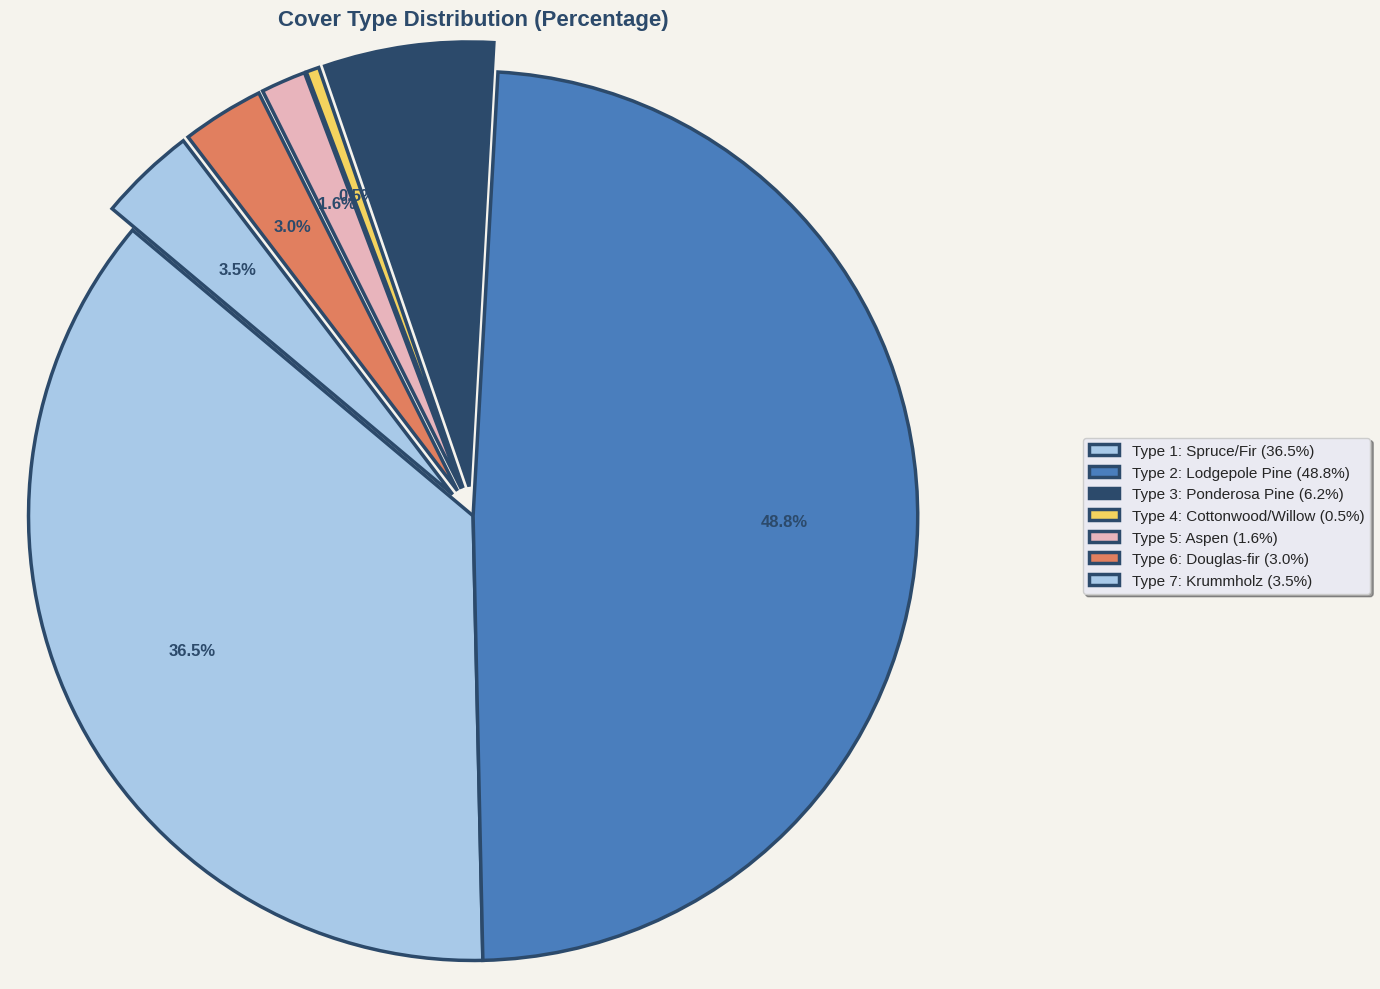

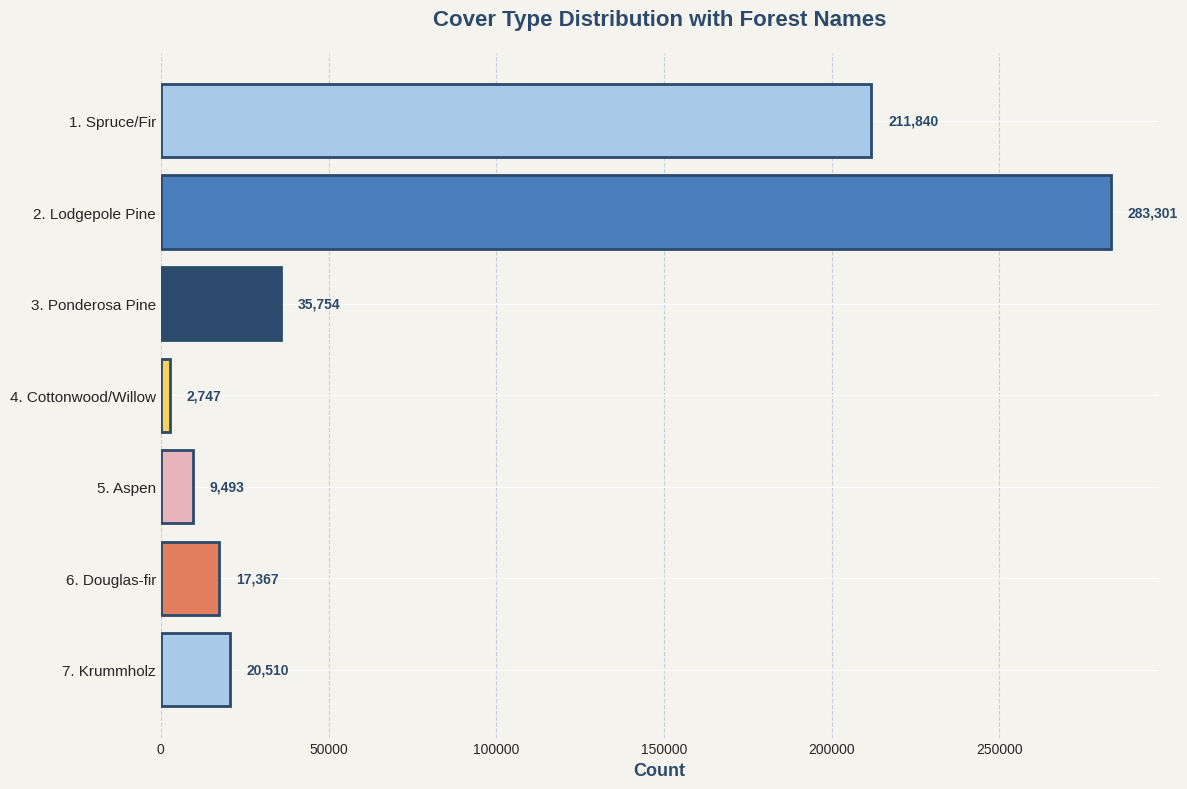

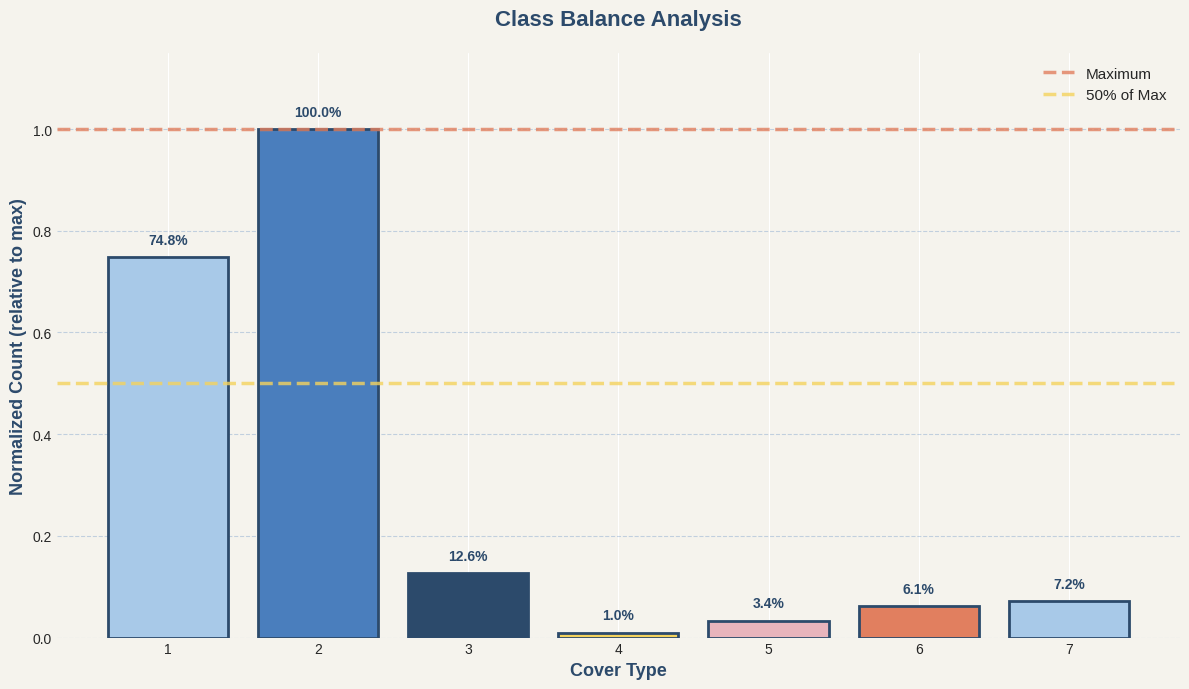

In [ ]:
from scipy.stats import chi2_contingency

colors = ['#A8C9E8', '#4A7EBD', '#2C4A6B', '#F4D35E', '#E8B4BC', '#E17F5F', '#A8C9E8']  # Baby, Captain, Deep, Sunshine, Rose, Poppy, Baby
primary_color = '#2C4A6B'      # Deep (for text and borders)
secondary_color = '#4A7EBD'    # Captain (for accents)
accent_color = '#F4D35E'       # Sunshine (for highlights)
bg_color = '#F5F3ED'
print("=" * 70)

print("\nIDENTIFYING FEATURE TYPES\n")

# Numerical features (continuous)
numerical_features = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
    'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points'
]

# Categorical features (binary one-hot encoded)
wilderness_features = [f'Wilderness_Area_{i}' for i in range(1, 5)]
soil_features = [f'Soil_Type_{i}' for i in range(1, 41)]
categorical_features = wilderness_features + soil_features

print(f"Total Features: {len(numerical_features) + len(categorical_features)}")
print(f"  Numerical Features: {len(numerical_features)}")
print(f"  Categorical Features: {len(categorical_features)}")
print(f"      - Wilderness Areas: {len(wilderness_features)}")
print(f"      - Soil Types: {len(soil_features)}")

print("\nNumerical Features:")
for i, feat in enumerate(numerical_features, 1):
    print(f"   {i:2d}. {feat}")

print("\nCategorical Features (Binary One-Hot Encoded):")
print(f"   - Wilderness_Area_1 to Wilderness_Area_4")
print(f"   - Soil_Type_1 to Soil_Type_40")

print("\n" + "=" * 70)
print("NUMERICAL FEATURES - DESCRIPTIVE STATISTICS")
print("=" * 70)

numerical_stats = df[numerical_features].describe().T
numerical_stats['range'] = numerical_stats['max'] - numerical_stats['min']
numerical_stats['variance'] = df[numerical_features].var()

print("\n", numerical_stats.round(2))

print("\n" + "=" * 70)
print("CORRELATION ANALYSIS - NUMERICAL FEATURES")
print("=" * 70)

# Calculate correlation matrix
correlation_matrix = df[numerical_features].corr()

# Find highly correlated pairs
print("\nHighly Correlated Feature Pairs (|correlation| > 0.5):\n")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            feat1 = correlation_matrix.columns[i]
            feat2 = correlation_matrix.columns[j]
            high_corr_pairs.append((feat1, feat2, corr_value))
            print(f"   • {feat1:40s} >>> {feat2:40s}: {corr_value:6.3f}")

if not high_corr_pairs:
    print("No highly correlated pairs found (all |r| < 0.5)")

# Figure 1: Bar Chart
fig1, ax1 = plt.subplots(figsize=(12, 7))
fig1.patch.set_facecolor(bg_color)

bars = ax1.bar(cover_counts.index, cover_counts.values, color=colors,
               edgecolor=primary_color, linewidth=2)
ax1.set_xlabel('Cover Type', fontsize=13, fontweight='bold', color=primary_color)
ax1.set_ylabel('Count', fontsize=13, fontweight='bold', color=primary_color)
ax1.set_title('Cover Type Distribution (Count)', fontsize=16, fontweight='bold',
              color=primary_color, pad=20)
ax1.set_xticks(range(1, 8))
ax1.grid(axis='y', alpha=0.3, linestyle='--', color=secondary_color)
ax1.set_facecolor(bg_color)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 3000,
             f'{int(height):,}', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=primary_color)

plt.tight_layout()
plt.savefig('cover_type_bar_chart.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

# Figure 2: Pie Chart
fig2, ax2 = plt.subplots(figsize=(14, 10))
fig2.patch.set_facecolor(bg_color)

wedges, texts, autotexts = ax2.pie(cover_percentages.values,
                                     autopct='%1.1f%%', startangle=140,
                                     colors=colors,
                                     wedgeprops={'edgecolor': primary_color, 'linewidth': 2.5},
                                     pctdistance=0.70,
                                     explode=[0, 0, 0.08, 0.08, 0.08, 0.08, 0.08],
                                     radius=1.2)
ax2.set_title('Cover Type Distribution (Percentage)', fontsize=16, fontweight='bold',
              color=primary_color, pad=20)

# Style the percentage text
for autotext in autotexts:
    autotext.set_color(primary_color)
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

# Create legend
legend_labels = [f'Type {i}: {cover_descriptions[i]} ({cover_percentages[i]:.1f}%)' for i in range(1, 8)]
ax2.legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1.15, 0.5),
          fontsize=11, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.savefig('cover_type_pie_chart.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

# Figure 3: Horizontal Bar Chart
fig3, ax3 = plt.subplots(figsize=(12, 8))
fig3.patch.set_facecolor(bg_color)

y_pos = np.arange(len(cover_descriptions))
bars = ax3.barh(y_pos, cover_counts.values, color=colors,
                edgecolor=primary_color, linewidth=2)
ax3.set_yticks(y_pos)
ax3.set_yticklabels([f"{i}. {cover_descriptions[i]}" for i in range(1, 8)], fontsize=11)
ax3.set_xlabel('Count', fontsize=13, fontweight='bold', color=primary_color)
ax3.set_title('Cover Type Distribution with Forest Names', fontsize=16, fontweight='bold',
              color=primary_color, pad=20)
ax3.grid(axis='x', alpha=0.3, linestyle='--', color=secondary_color)
ax3.set_facecolor(bg_color)
ax3.invert_yaxis()  # Highest at top

# Add count labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 5000, bar.get_y() + bar.get_height()/2.,
             f'{int(width):,}', ha='left', va='center',
             fontsize=10, fontweight='bold', color=primary_color)

plt.tight_layout()
plt.savefig('cover_type_horizontal_bar.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

# Figure 4: Class Balance
fig4, ax4 = plt.subplots(figsize=(12, 7))
fig4.patch.set_facecolor(bg_color)

normalized_counts = cover_counts.values / cover_counts.max()
bars = ax4.bar(cover_counts.index, normalized_counts, color=colors,
               edgecolor=primary_color, linewidth=2)
ax4.axhline(y=1.0, color='#E17F5F', linestyle='--', linewidth=2.5, label='Maximum', alpha=0.8)
ax4.axhline(y=0.5, color='#F4D35E', linestyle='--', linewidth=2.5, label='50% of Max', alpha=0.8)
ax4.set_xlabel('Cover Type', fontsize=13, fontweight='bold', color=primary_color)
ax4.set_ylabel('Normalized Count (relative to max)', fontsize=13, fontweight='bold', color=primary_color)
ax4.set_title('Class Balance Analysis', fontsize=16, fontweight='bold',
              color=primary_color, pad=20)
ax4.set_xticks(range(1, 8))
ax4.set_ylim([0, 1.15])
ax4.legend(loc='upper right', framealpha=0.9, fontsize=11)
ax4.grid(axis='y', alpha=0.3, linestyle='--', color=secondary_color)
ax4.set_facecolor(bg_color)

# Add percentage labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height*100:.1f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=primary_color)

plt.tight_layout()
plt.savefig('cover_type_balance_analysis.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

## Data preprocessing

### Seperate features

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

numerical_features = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
    'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points'
]

wilderness_features = [f'Wilderness_Area_{i}' for i in range(1, 5)]
soil_features = [f'Soil_Type_{i}' for i in range(1, 41)]
categorical_features = wilderness_features + soil_features

# All features
all_features = numerical_features + categorical_features

# Separate X and y
X = df[all_features]
y = df['Cover_Type']

print(f"   Features (X) shape: {X.shape}")
print(f"   Target (y) shape: {y.shape}")
print(f"   Total features: {len(all_features)}")
print(f"      - Numerical: {len(numerical_features)}")
print(f"      - Categorical (binary): {len(categorical_features)}")

# Check balance
class_distribution = y.value_counts().sort_index()
class_percentages = (y.value_counts(normalize=True).sort_index() * 100).round(2)

print("\n   Cover Type Distribution:")
for cover_type in range(1, 8):
    count = class_distribution[cover_type]
    pct = class_percentages[cover_type]
    print(f"      Type {cover_type}: {count:7,} samples ({pct:5.2f}%)")

# Calculate imbalance ratio
max_class_count = class_distribution.max()
min_class_count = class_distribution.min()
imbalance_ratio = max_class_count / min_class_count

print(f"\n   Imbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 3:
    print("   Status: MODERATE IMBALANCE - Using stratified split")
    use_stratify = True
elif imbalance_ratio > 1.5:
    print("   Status: SLIGHT IMBALANCE - Using stratified split recommended")
    use_stratify = True
else:
    print("   Status: WELL BALANCED - Stratified split optional")
    use_stratify = True

   Features (X) shape: (581012, 54)
   Target (y) shape: (581012,)
   Total features: 54
      - Numerical: 10
      - Categorical (binary): 44

   Cover Type Distribution:
      Type 1: 211,840 samples (36.46%)
      Type 2: 283,301 samples (48.76%)
      Type 3:  35,754 samples ( 6.15%)
      Type 4:   2,747 samples ( 0.47%)
      Type 5:   9,493 samples ( 1.63%)
      Type 6:  17,367 samples ( 2.99%)
      Type 7:  20,510 samples ( 3.53%)

   Imbalance Ratio: 103.13:1
   Status: MODERATE IMBALANCE - Using stratified split


### Train-test

In [ ]:
# Using 70/30 split with stratification
test_size = 0.30
random_state = 42

if use_stratify:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    print(f"   Split: 70% train / 30% test (stratified)")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state
    )
    print(f"   Split: 70% train / 30% test")

print(f"\n   Training set: {X_train.shape[0]:,} samples")
print(f"   Test set: {X_test.shape[0]:,} samples")

# Verify stratification
print("\n   Class Distribution in Training Set:")
train_dist = y_train.value_counts(normalize=True).sort_index() * 100
for cover_type in range(1, 8):
    print(f"      Type {cover_type}: {train_dist[cover_type]:5.2f}%")

print("\n   Class Distribution in Test Set:")
test_dist = y_test.value_counts(normalize=True).sort_index() * 100
for cover_type in range(1, 8):
    print(f"      Type {cover_type}: {test_dist[cover_type]:5.2f}%")

   Split: 70% train / 30% test (stratified)

   Training set: 406,708 samples
   Test set: 174,304 samples

   Class Distribution in Training Set:
      Type 1: 36.46%
      Type 2: 48.76%
      Type 3:  6.15%
      Type 4:  0.47%
      Type 5:  1.63%
      Type 6:  2.99%
      Type 7:  3.53%

   Class Distribution in Test Set:
      Type 1: 36.46%
      Type 2: 48.76%
      Type 3:  6.15%
      Type 4:  0.47%
      Type 5:  1.63%
      Type 6:  2.99%
      Type 7:  3.53%


### Feature scaling

In [ ]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data only
X_train_numerical = X_train[numerical_features]
X_test_numerical = X_test[numerical_features]

X_train_numerical_scaled = scaler.fit_transform(X_train_numerical)
X_test_numerical_scaled = scaler.transform(X_test_numerical)

# Convert back to DataFrame for easier handling
X_train_numerical_scaled = pd.DataFrame(
    X_train_numerical_scaled,
    columns=numerical_features,
    index=X_train.index
)

X_test_numerical_scaled = pd.DataFrame(
    X_test_numerical_scaled,
    columns=numerical_features,
    index=X_test.index
)

# Combine scaled numerical with categorical features
X_train_processed = pd.concat([
    X_train_numerical_scaled,
    X_train[categorical_features]
], axis=1)

X_test_processed = pd.concat([
    X_test_numerical_scaled,
    X_test[categorical_features]
], axis=1)

print(f"\n   Processed training set shape: {X_train_processed.shape}")
print(f"   Processed test set shape: {X_test_processed.shape}")

print("\nVerification of Preprocessing")

print("\n   Numerical Features - Before Scaling (Training Set):")
print(X_train[numerical_features].describe().loc[['mean', 'std', 'min', 'max']].round(2))

print("\n   Numerical Features - After Scaling (Training Set):")
print(X_train_numerical_scaled.describe().loc[['mean', 'std', 'min', 'max']].round(2))

print("\n   Categorical Features (unchanged):")
print(f"      Total binary features: {len(categorical_features)}")
print(f"      Value range: {X_train_processed[categorical_features].min().min()} to {X_train_processed[categorical_features].max().max()}")


   Processed training set shape: (406708, 54)
   Processed test set shape: (174304, 54)

Verification of Preprocessing

   Numerical Features - Before Scaling (Training Set):
      Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
mean    2959.53  155.76  14.11                            269.36   
std      280.12  111.96   7.49                            212.38   
min     1860.00    0.00   0.00                              0.00   
max     3858.00  360.00  65.00                           1397.00   

      Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
mean                           46.45                          2350.54   
std                            58.30                          1558.69   
min                          -166.00                             0.00   
max                           601.00                          7117.00   

      Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
mean         212.13          223.32         142.54   
std      

## Baseline Model

### Logistic regression model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import time

primary_color = '#2C4A6B'
secondary_color = '#4A7EBD'
bg_color = '#F5F3ED'

# Initialize the model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial',
    solver='lbfgs',
    n_jobs=-1
)

# Train the model
start_time = time.time()
lr_model.fit(X_train_processed, y_train)
training_time = time.time() - start_time

print(f"Model trained successfully")
print(f"   Training time: {training_time:.2f} seconds")
print(f"   Number of iterations: {lr_model.n_iter_[0]}")

print("\nMaking Predictions on Test Set")

# Predictions on training set
start_time = time.time()
y_train_pred = lr_model.predict(X_train_processed)
train_pred_time = time.time() - start_time

# Predictions on test set
start_time = time.time()
y_test_pred = lr_model.predict(X_test_processed)
test_pred_time = time.time() - start_time

print(f"   Training set predictions: {len(y_train_pred):,} samples ({train_pred_time:.2f}s)")
print(f"   Test set predictions: {len(y_test_pred):,} samples ({test_pred_time:.2f}s)")

Model trained successfully
   Training time: 59.47 seconds
   Number of iterations: 226

Making Predictions on Test Set
   Training set predictions: 406,708 samples (0.42s)
   Test set predictions: 174,304 samples (0.17s)


### Calculate accuracy score

In [ ]:
# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Precision, Recall, F1-Score (weighted average)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
test_precision = precision_score(y_test, y_test_pred, average='weighted')

train_recall = recall_score(y_train, y_train_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')

train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\n   Training Set Performance:")
print(f"      Accuracy:  {train_accuracy:.4f}")
print(f"      Precision: {train_precision:.4f}")
print(f"      Recall:    {train_recall:.4f}")
print(f"      F1-Score:  {train_f1:.4f}")

print("\n   Test Set Performance:")
print(f"      Accuracy:  {test_accuracy:.4f}")
print(f"      Precision: {test_precision:.4f}")
print(f"      Recall:    {test_recall:.4f}")
print(f"      F1-Score:  {test_f1:.4f}")

# Check for overfitting
accuracy_diff = train_accuracy - test_accuracy
if accuracy_diff > 0.05:
    print(f"\n   Note: Model shows signs of overfitting (difference: {accuracy_diff:.4f})")
else:
    print(f"\n   Note: Model generalizes well (difference: {accuracy_diff:.4f})")


   Training Set Performance:
      Accuracy:  0.7245
      Precision: 0.7128
      Recall:    0.7245
      F1-Score:  0.7149

   Test Set Performance:
      Accuracy:  0.7245
      Precision: 0.7125
      Recall:    0.7245
      F1-Score:  0.7150

   Note: Model generalizes well (difference: -0.0000)


### Confusion matrix


   Confusion Matrix (Counts):
[[44382 17926    18     0     0    24  1202]
 [15257 68095  1073     4    60   461    41]
 [    0  1109  8530   195    10   882     0]
 [    0     5   378   344     0    97     0]
 [   12  2722    81     0    16    17     0]
 [    0  1182  2533    18     4  1473     0]
 [ 2645    59     0     0     0     0  3449]]

   Confusion Matrix (Normalized by True Label):
[[0.698 0.282 0.    0.    0.    0.    0.019]
 [0.18  0.801 0.013 0.    0.001 0.005 0.   ]
 [0.    0.103 0.795 0.018 0.001 0.082 0.   ]
 [0.    0.006 0.459 0.417 0.    0.118 0.   ]
 [0.004 0.956 0.028 0.    0.006 0.006 0.   ]
 [0.    0.227 0.486 0.003 0.001 0.283 0.   ]
 [0.43  0.01  0.    0.    0.    0.    0.561]]


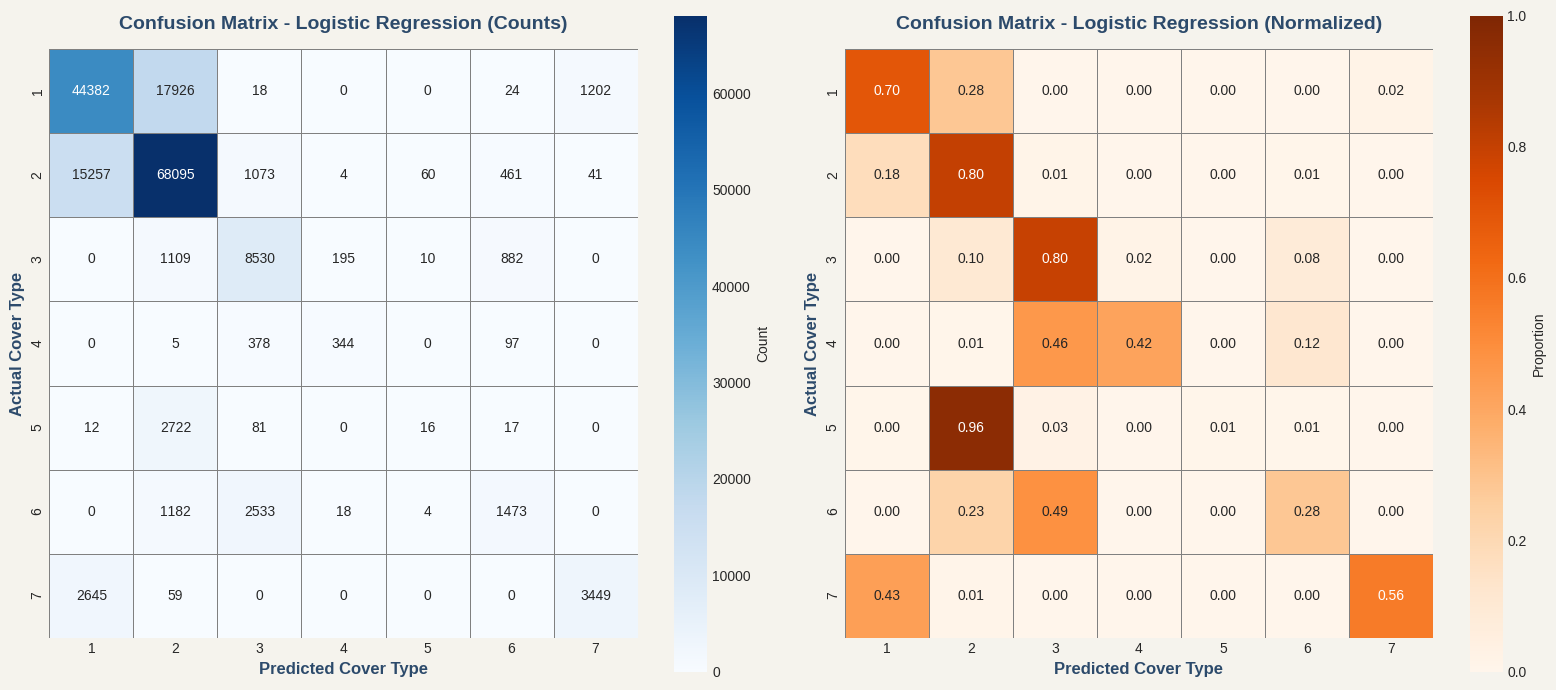


   Per-Class Accuracy:
      Cover Type 1: 0.6984
      Cover Type 2: 0.8012
      Cover Type 3: 0.7953
      Cover Type 4: 0.4175
      Cover Type 5: 0.0056
      Cover Type 6: 0.2827
      Cover Type 7: 0.5605


In [ ]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_normalized = confusion_matrix(y_test, y_test_pred, normalize='true')

print("\n   Confusion Matrix (Counts):")
print(cm)

print("\n   Confusion Matrix (Normalized by True Label):")
print(cm_normalized.round(3))

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(bg_color)

# Subplot 1: Raw counts
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=range(1, 8), yticklabels=range(1, 8),
            cbar_kws={'label': 'Count'}, ax=ax1, linewidths=0.5, linecolor='gray')
ax1.set_xlabel('Predicted Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax1.set_ylabel('Actual Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax1.set_title('Confusion Matrix - Logistic Regression (Counts)',
              fontsize=14, fontweight='bold', color=primary_color, pad=15)
ax1.set_facecolor(bg_color)

# Subplot 2: Normalized
ax2 = axes[1]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Oranges', square=True,
            xticklabels=range(1, 8), yticklabels=range(1, 8),
            cbar_kws={'label': 'Proportion'}, ax=ax2, linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1)
ax2.set_xlabel('Predicted Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax2.set_ylabel('Actual Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax2.set_title('Confusion Matrix - Logistic Regression (Normalized)',
              fontsize=14, fontweight='bold', color=primary_color, pad=15)
ax2.set_facecolor(bg_color)

plt.tight_layout()
plt.savefig('confusion_matrix_logistic_regression.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

# Calculate per-class accuracy
per_class_accuracy = cm_normalized.diagonal()
print("\n   Per-Class Accuracy:")
for i, acc in enumerate(per_class_accuracy, 1):
    print(f"      Cover Type {i}: {acc:.4f}")

### Classification report


              precision    recall  f1-score   support

      Type 1     0.7124    0.6984    0.7053     63552
      Type 2     0.7475    0.8012    0.7734     84991
      Type 3     0.6763    0.7953    0.7310     10726
      Type 4     0.6132    0.4175    0.4968       824
      Type 5     0.1778    0.0056    0.0109      2848
      Type 6     0.4986    0.2827    0.3609      5210
      Type 7     0.7351    0.5605    0.6361      6153

    accuracy                         0.7245    174304
   macro avg     0.5944    0.5087    0.5306    174304
weighted avg     0.7125    0.7245    0.7150    174304


   Classification Report (Table Format):
              precision  recall  f1-score      support
Type 1           0.7124  0.6984    0.7053   63552.0000
Type 2           0.7475  0.8012    0.7734   84991.0000
Type 3           0.6763  0.7953    0.7310   10726.0000
Type 4           0.6132  0.4175    0.4968     824.0000
Type 5           0.1778  0.0056    0.0109    2848.0000
Type 6           0.4986  0.282

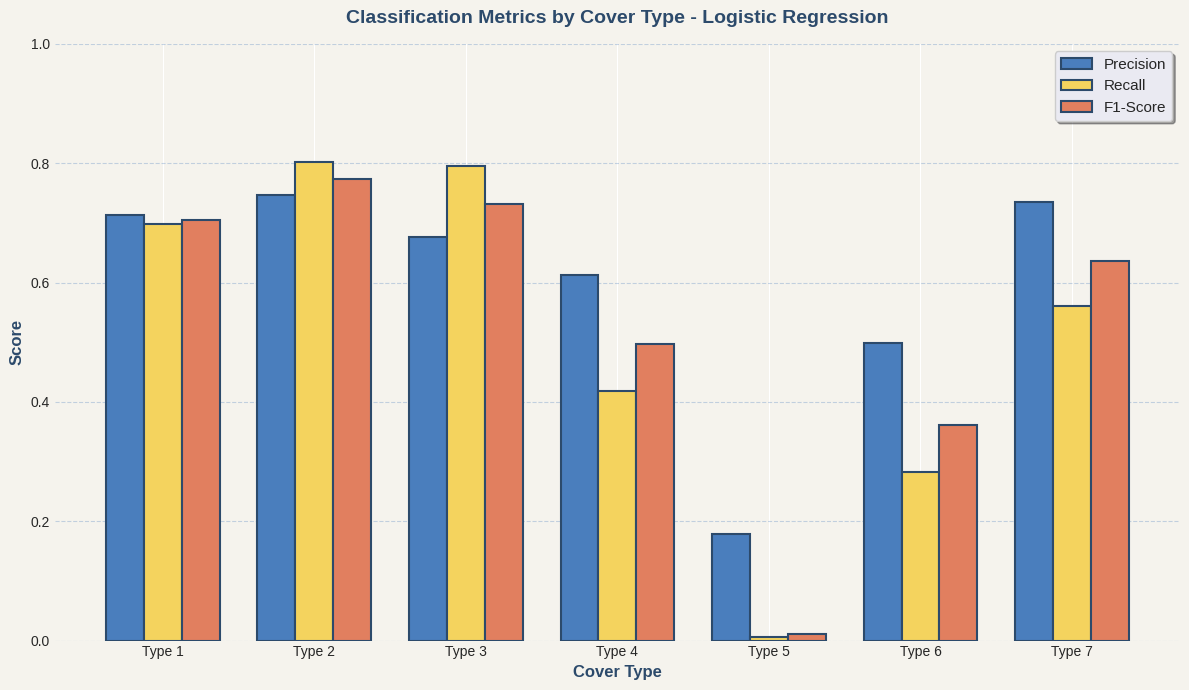

In [ ]:
class_report = classification_report(y_test, y_test_pred,
                                     target_names=[f'Type {i}' for i in range(1, 8)],
                                     digits=4)
print("\n" + class_report)

# Convert to DataFrame for better visualization
report_dict = classification_report(y_test, y_test_pred,
                                    target_names=[f'Type {i}' for i in range(1, 8)],
                                    output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("\n   Classification Report (Table Format):")
print(report_df.round(4))

# Visualize classification metrics
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(bg_color)

metrics_df = report_df.iloc[:7, :3]
x = np.arange(len(metrics_df.index))
width = 0.25

bars1 = ax.bar(x - width, metrics_df['precision'], width, label='Precision',
               color='#4A7EBD', edgecolor=primary_color, linewidth=1.5)
bars2 = ax.bar(x, metrics_df['recall'], width, label='Recall',
               color='#F4D35E', edgecolor=primary_color, linewidth=1.5)
bars3 = ax.bar(x + width, metrics_df['f1-score'], width, label='F1-Score',
               color='#E17F5F', edgecolor=primary_color, linewidth=1.5)

ax.set_xlabel('Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax.set_ylabel('Score', fontsize=12, fontweight='bold', color=primary_color)
ax.set_title('Classification Metrics by Cover Type - Logistic Regression',
             fontsize=14, fontweight='bold', color=primary_color, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index)
ax.legend(loc='upper right', fontsize=11, frameon=True, fancybox=True, shadow=True)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--', color=secondary_color)
ax.set_facecolor(bg_color)

plt.tight_layout()
plt.savefig('classification_metrics_logistic_regression.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

## XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import time

# Custom color palette
primary_color = '#2C4A6B'
secondary_color = '#4A7EBD'
accent_color = '#F4D35E'
bg_color = '#F5F3ED'

print("XGBOOST CLASSIFIER")

print("\nTraining XGBoost Model")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    tree_method='hist'
)

start_time = time.time()
# Subtract 1 from the target variable to make it 0-indexed
xgb_model.fit(X_train_processed, y_train - 1)
training_time = time.time() - start_time

print(f"   Model trained successfully")
print(f"   Training time: {training_time:.2f} seconds")
print(f"   Number of trees: {xgb_model.n_estimators}")
print(f"   Max depth: {xgb_model.max_depth}")
print(f"   Learning rate: {xgb_model.learning_rate}")

print("\nMaking Predictions")

y_train_pred_xgb = xgb_model.predict(X_train_processed)
y_test_pred_xgb = xgb_model.predict(X_test_processed)

# Add 1 back to predictions to match original class labels
y_train_pred_xgb += 1
y_test_pred_xgb += 1

print(f"   Training predictions: {len(y_train_pred_xgb):,} samples")
print(f"   Test predictions: {len(y_test_pred_xgb):,} samples")

print("\nModel Performance Metrics")

train_accuracy_xgb = accuracy_score(y_train, y_train_pred_xgb)
test_accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)

train_precision_xgb = precision_score(y_train, y_train_pred_xgb, average='weighted')
test_precision_xgb = precision_score(y_test, y_test_pred_xgb, average='weighted')

train_recall_xgb = recall_score(y_train, y_train_pred_xgb, average='weighted')
test_recall_xgb = recall_score(y_test, y_test_pred_xgb, average='weighted')

train_f1_xgb = f1_score(y_train, y_train_pred_xgb, average='weighted')
test_f1_xgb = f1_score(y_test, y_test_pred_xgb, average='weighted')

print("\n   Training Set Performance:")
print(f"      Accuracy:  {train_accuracy_xgb:.4f}")
print(f"      Precision: {train_precision_xgb:.4f}")
print(f"      Recall:    {train_recall_xgb:.4f}")
print(f"      F1-Score:  {train_f1_xgb:.4f}")

print("\n   Test Set Performance:")
print(f"      Accuracy:  {test_accuracy_xgb:.4f}")
print(f"      Precision: {test_precision_xgb:.4f}")
print(f"      Recall:    {test_recall_xgb:.4f}")
print(f"      F1-Score:  {test_f1_xgb:.4f}")

accuracy_diff_xgb = train_accuracy_xgb - test_accuracy_xgb
if accuracy_diff_xgb > 0.05:
    print(f"\nModel shows signs of overfitting (difference: {accuracy_diff_xgb:.4f})")
else:
    print(f"\nModel generalizes well (difference: {accuracy_diff_xgb:.4f})")

print("\nComparison with Random Forest")

print("\n   Performance Comparison:")
print(f"      {'Metric':<15} {'Random Forest':<15} {'XGBoost':<15} {'Difference':<15}")
print("   " + "-" * 60)
print(f"      {'Accuracy':<15} {test_accuracy_rf:.4f}          {test_accuracy_xgb:.4f}          {(test_accuracy_xgb - test_accuracy_rf):.4f}")
print(f"      {'Precision':<15} {test_precision_rf:.4f}          {test_precision_xgb:.4f}          {(test_precision_xgb - test_precision_rf):.4f}")
print(f"      {'Recall':<15} {test_recall_rf:.4f}          {test_recall_xgb:.4f}          {(test_recall_xgb - test_recall_rf):.4f}")
print(f"      {'F1-Score':<15} {test_f1_rf:.4f}          {test_f1_xgb:.4f}          {(test_f1_xgb - test_f1_rf):.4f}")

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(bg_color)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_scores = [test_accuracy_rf, test_precision_rf, test_recall_rf, test_f1_rf]
xgb_scores = [test_accuracy_xgb, test_precision_xgb, test_recall_xgb, test_f1_xgb]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest',
               color='#4A7EBD', edgecolor=primary_color, linewidth=1.5)
bars2 = ax.bar(x + width/2, xgb_scores, width, label='XGBoost',
               color='#E17F5F', edgecolor=primary_color, linewidth=1.5)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold', color=primary_color)
ax.set_ylabel('Score', fontsize=12, fontweight='bold', color=primary_color)
ax.set_title('Model Comparison: Random Forest vs XGBoost',
             fontsize=14, fontweight='bold', color=primary_color, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='upper right', fontsize=11, frameon=True, fancybox=True, shadow=True)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--', color=secondary_color)
ax.set_facecolor(bg_color)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_rf_vs_xgb.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

print("\nFeature Importance Analysis")

feature_importance_xgb = pd.DataFrame({
    'feature': X_train_processed.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n   Top 20 Most Important Features:")
print(feature_importance_xgb.head(20).to_string(index=False))

# Visualize top 20 features
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(bg_color)

top_features = feature_importance_xgb.head(20)
colors_gradient = plt.cm.Oranges(np.linspace(0.4, 0.8, len(top_features)))

bars = ax.barh(range(len(top_features)), top_features['importance'].values,
               color=colors_gradient, edgecolor=primary_color, linewidth=1.5)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values, fontsize=10)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold', color=primary_color)
ax.set_title('Top 20 Feature Importance - XGBoost',
             fontsize=14, fontweight='bold', color=primary_color, pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--', color=secondary_color)
ax.set_facecolor(bg_color)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.001, bar.get_y() + bar.get_height()/2.,
            f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_xgboost.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

# Compare feature importance between RF and XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor(bg_color)

# Get top 15 features from each model
top_rf = feature_importance.head(15)
top_xgb = feature_importance_xgb.head(15)

ax1 = axes[0]
colors_rf = plt.cm.Blues(np.linspace(0.4, 0.8, len(top_rf)))
bars = ax1.barh(range(len(top_rf)), top_rf['importance'].values,
                color=colors_rf, edgecolor=primary_color, linewidth=1.5)
ax1.set_yticks(range(len(top_rf)))
ax1.set_yticklabels(top_rf['feature'].values, fontsize=9)
ax1.set_xlabel('Importance Score', fontsize=11, fontweight='bold', color=primary_color)
ax1.set_title('Random Forest - Top 15 Features',
              fontsize=12, fontweight='bold', color=primary_color, pad=15)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, linestyle='--', color=secondary_color)
ax1.set_facecolor(bg_color)

ax2 = axes[1]
colors_xgb = plt.cm.Oranges(np.linspace(0.4, 0.8, len(top_xgb)))
bars = ax2.barh(range(len(top_xgb)), top_xgb['importance'].values,
                color=colors_xgb, edgecolor=primary_color, linewidth=1.5)
ax2.set_yticks(range(len(top_xgb)))
ax2.set_yticklabels(top_xgb['feature'].values, fontsize=9)
ax2.set_xlabel('Importance Score', fontsize=11, fontweight='bold', color=primary_color)
ax2.set_title('XGBoost - Top 15 Features',
              fontsize=12, fontweight='bold', color=primary_color, pad=15)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3, linestyle='--', color=secondary_color)
ax2.set_facecolor(bg_color)

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

print("\nConfusion Matrix Analysis")

cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
cm_xgb_normalized = confusion_matrix(y_test, y_test_pred_xgb, normalize='true')

print("\n   Confusion Matrix (Counts):")
print(cm_xgb)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(bg_color)

ax1 = axes[0]
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=range(1, 8), yticklabels=range(1, 8),
            cbar_kws={'label': 'Count'}, ax=ax1, linewidths=0.5, linecolor='gray')
ax1.set_xlabel('Predicted Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax1.set_ylabel('Actual Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax1.set_title('Confusion Matrix - XGBoost (Counts)',
              fontsize=14, fontweight='bold', color=primary_color, pad=15)
ax1.set_facecolor(bg_color)

ax2 = axes[1]
sns.heatmap(cm_xgb_normalized, annot=True, fmt='.2f', cmap='Oranges', square=True,
            xticklabels=range(1, 8), yticklabels=range(1, 8),
            cbar_kws={'label': 'Proportion'}, ax=ax2, linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1)
ax2.set_xlabel('Predicted Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax2.set_ylabel('Actual Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax2.set_title('Confusion Matrix - XGBoost (Normalized)',
              fontsize=14, fontweight='bold', color=primary_color, pad=15)
ax2.set_facecolor(bg_color)

plt.tight_layout()
plt.savefig('confusion_matrix_xgboost.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

per_class_accuracy_xgb = cm_xgb_normalized.diagonal()
print("\n   Per-Class Accuracy:")
for i, acc in enumerate(per_class_accuracy_xgb, 1):
    print(f"      Cover Type {i}: {acc:.4f}")

print("\nClassification Report")

class_report_xgb = classification_report(y_test, y_test_pred_xgb,
                                         target_names=[f'Type {i}' for i in range(1, 8)],
                                         digits=4)
print("\n" + class_report_xgb)

print("XGBOOST MODEL SUMMARY")
print("=" * 70)

print(f"\nModel Performance:")
print(f"   Test Accuracy: {test_accuracy_xgb:.4f} ({test_accuracy_xgb*100:.2f}%)")
print(f"   Test F1-Score: {test_f1_xgb:.4f}")
print(f"   Improvement over Random Forest: {(test_accuracy_xgb - test_accuracy_rf):.4f}")

print(f"\nTraining Details:")
print(f"   Training time: {training_time:.2f} seconds")
print(f"   Number of trees: {xgb_model.n_estimators}")
print(f"   Max depth: {xgb_model.max_depth}")
print(f"   Learning rate: {xgb_model.learning_rate}")

print(f"\nTop 3 Most Important Features:")
for i, row in feature_importance_xgb.head(3).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

XGBOOST CLASSIFIER

Training XGBoost Model


## Random Forest Classifier

RANDOM FOREST CLASSIFIER

Training Random Forest Model
   Model trained successfully
   Training time: 120.48 seconds
   Number of trees: 100
   Max depth: 20

Making Predictions
   Training predictions: 406,708 samples
   Test predictions: 174,304 samples

Model Performance Metrics

   Training Set Performance:
      Accuracy:  0.9370
      Precision: 0.9424
      Recall:    0.9370
      F1-Score:  0.9384

   Test Set Performance:
      Accuracy:  0.8975
      Precision: 0.9036
      Recall:    0.8975
      F1-Score:  0.8992

Model generalizes well (difference: 0.0395)

Confusion Matrix Analysis

   Confusion Matrix (Counts):
[[56649  5835    19     0   443    76   530]
 [ 5801 75789   577     5  1981   778    60]
 [    0    98  9984    83    58   503     0]
 [    0     0    68   734     0    22     0]
 [    5   199    29     0  2597    18     0]
 [    0    65   336    39    19  4751     0]
 [  207    17     0     0     2     0  5927]]


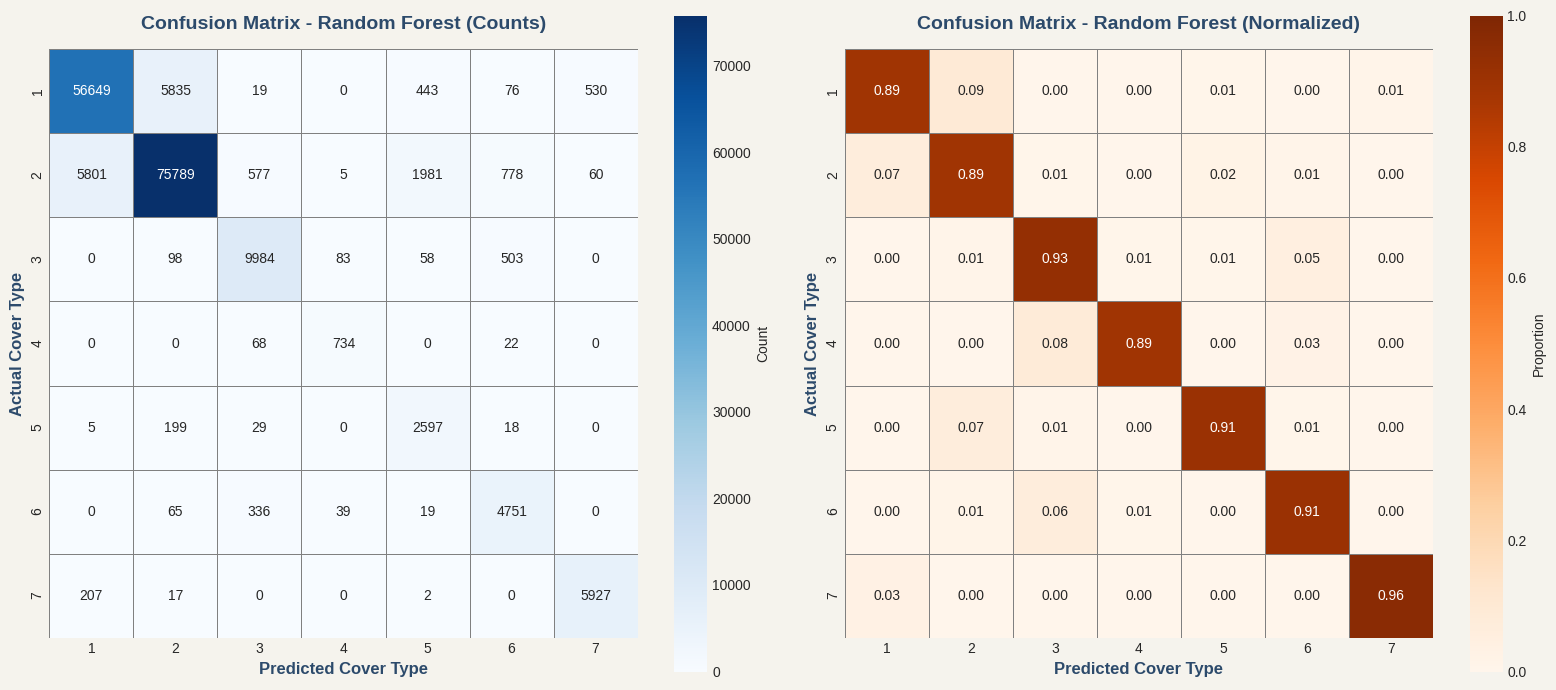


   Per-Class Accuracy:
      Cover Type 1: 0.8914
      Cover Type 2: 0.8917
      Cover Type 3: 0.9308
      Cover Type 4: 0.8908
      Cover Type 5: 0.9119
      Cover Type 6: 0.9119
      Cover Type 7: 0.9633

Classification Report

              precision    recall  f1-score   support

      Type 1     0.9040    0.8914    0.8977     63552
      Type 2     0.9242    0.8917    0.9077     84991
      Type 3     0.9066    0.9308    0.9185     10726
      Type 4     0.8525    0.8908    0.8712       824
      Type 5     0.5092    0.9119    0.6535      2848
      Type 6     0.7728    0.9119    0.8366      5210
      Type 7     0.9095    0.9633    0.9356      6153

    accuracy                         0.8975    174304
   macro avg     0.8255    0.9131    0.8601    174304
weighted avg     0.9036    0.8975    0.8992    174304


Feature Importance Analysis (Top 20 Features)
                           feature  importance
                         Elevation    0.250848
   Horizontal_Distance_To

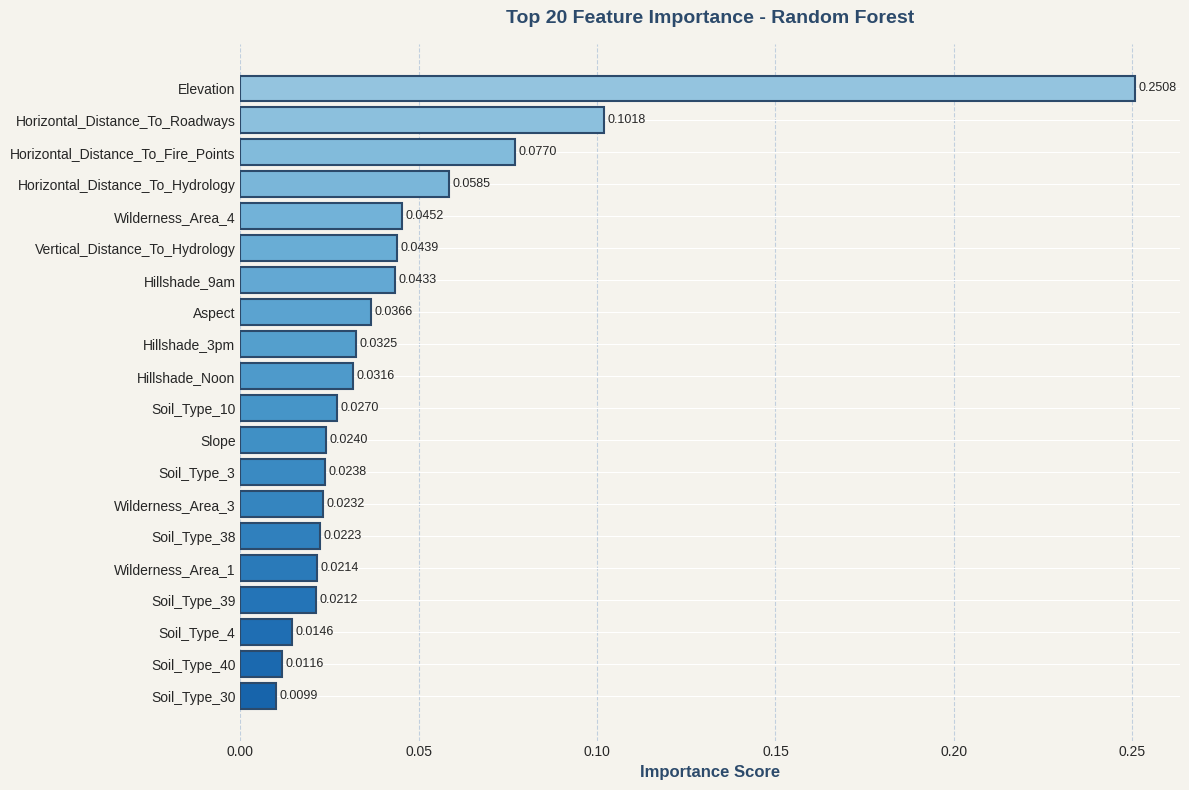

In [49]:
from sklearn.ensemble import RandomForestClassifier
import time

print("RANDOM FOREST CLASSIFIER")

print("\nTraining Random Forest Model")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced' # Handle class imbalance
)

start_time = time.time()
rf_model.fit(X_train_processed, y_train)
training_time_rf = time.time() - start_time

print(f"   Model trained successfully")
print(f"   Training time: {training_time_rf:.2f} seconds")
print(f"   Number of trees: {rf_model.n_estimators}")
print(f"   Max depth: {rf_model.max_depth}")

print("\nMaking Predictions")

y_train_pred_rf = rf_model.predict(X_train_processed)
y_test_pred_rf = rf_model.predict(X_test_processed)

print(f"   Training predictions: {len(y_train_pred_rf):,} samples")
print(f"   Test predictions: {len(y_test_pred_rf):,} samples")

print("\nModel Performance Metrics")

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

train_precision_rf = precision_score(y_train, y_train_pred_rf, average='weighted')
test_precision_rf = precision_score(y_test, y_test_pred_rf, average='weighted')

train_recall_rf = recall_score(y_train, y_train_pred_rf, average='weighted')
test_recall_rf = recall_score(y_test, y_test_pred_rf, average='weighted')

train_f1_rf = f1_score(y_train, y_train_pred_rf, average='weighted')
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='weighted')

print("\n   Training Set Performance:")
print(f"      Accuracy:  {train_accuracy_rf:.4f}")
print(f"      Precision: {train_precision_rf:.4f}")
print(f"      Recall:    {train_recall_rf:.4f}")
print(f"      F1-Score:  {train_f1_rf:.4f}")

print("\n   Test Set Performance:")
print(f"      Accuracy:  {test_accuracy_rf:.4f}")
print(f"      Precision: {test_precision_rf:.4f}")
print(f"      Recall:    {test_recall_rf:.4f}")
print(f"      F1-Score:  {test_f1_rf:.4f}")

accuracy_diff_rf = train_accuracy_rf - test_accuracy_rf
if accuracy_diff_rf > 0.05:
    print(f"\nModel shows signs of overfitting (difference: {accuracy_diff_rf:.4f})")
else:
    print(f"\nModel generalizes well (difference: {accuracy_diff_rf:.4f})")

print("\nConfusion Matrix Analysis")

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
cm_rf_normalized = confusion_matrix(y_test, y_test_pred_rf, normalize='true')

print("\n   Confusion Matrix (Counts):")
print(cm_rf)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(bg_color)

ax1 = axes[0]
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=range(1, 8), yticklabels=range(1, 8),
            cbar_kws={'label': 'Count'}, ax=ax1, linewidths=0.5, linecolor='gray')
ax1.set_xlabel('Predicted Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax1.set_ylabel('Actual Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax1.set_title('Confusion Matrix - Random Forest (Counts)',
              fontsize=14, fontweight='bold', color=primary_color, pad=15)
ax1.set_facecolor(bg_color)

ax2 = axes[1]
sns.heatmap(cm_rf_normalized, annot=True, fmt='.2f', cmap='Oranges', square=True,
            xticklabels=range(1, 8), yticklabels=range(1, 8),
            cbar_kws={'label': 'Proportion'}, ax=ax2, linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1)
ax2.set_xlabel('Predicted Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax2.set_ylabel('Actual Cover Type', fontsize=12, fontweight='bold', color=primary_color)
ax2.set_title('Confusion Matrix - Random Forest (Normalized)',
              fontsize=14, fontweight='bold', color=primary_color, pad=15)
ax2.set_facecolor(bg_color)

plt.tight_layout()
plt.savefig('confusion_matrix_random_forest.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

per_class_accuracy_rf = cm_rf_normalized.diagonal()
print("\n   Per-Class Accuracy:")
for i, acc in enumerate(per_class_accuracy_rf, 1):
    print(f"      Cover Type {i}: {acc:.4f}")

print("\nClassification Report")

class_report_rf = classification_report(y_test, y_test_pred_rf,
                                        target_names=[f'Type {i}' for i in range(1, 8)],
                                        digits=4)
print("\n" + class_report_rf)

print("\nFeature Importance Analysis (Top 20 Features)")

feature_importance = pd.DataFrame({
    'feature': X_train_processed.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(20).to_string(index=False))

# Visualize top 20 features
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(bg_color)

top_features_rf = feature_importance.head(20)
colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.8, len(top_features_rf)))

bars = ax.barh(range(len(top_features_rf)), top_features_rf['importance'].values,
               color=colors_gradient, edgecolor=primary_color, linewidth=1.5)
ax.set_yticks(range(len(top_features_rf)))
ax.set_yticklabels(top_features_rf['feature'].values, fontsize=10)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold', color=primary_color)
ax.set_title('Top 20 Feature Importance - Random Forest',
             fontsize=14, fontweight='bold', color=primary_color, pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--', color=secondary_color)
ax.set_facecolor(bg_color)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.001, bar.get_y() + bar.get_height()/2.,
            f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_random_forest.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

## Final model comparison

FINAL MODEL COMPARISON

Comprehensive Performance Comparison

              Model  Accuracy  Precision   Recall  F1-Score  Training Time (s)
Logistic Regression  0.724533   0.712509 0.724533  0.715030          82.675235
      Random Forest  0.897461   0.903610 0.897461  0.899234          82.675235
            XGBoost  0.900329   0.900705 0.900329  0.899560          82.675235

   Best Models by Metric:
      Accuracy:  XGBoost (0.9003)
      Precision: Random Forest (0.9036)
      Recall:    XGBoost (0.9003)
      F1-Score:  XGBoost (0.8996)

Generating Comprehensive Visualizations


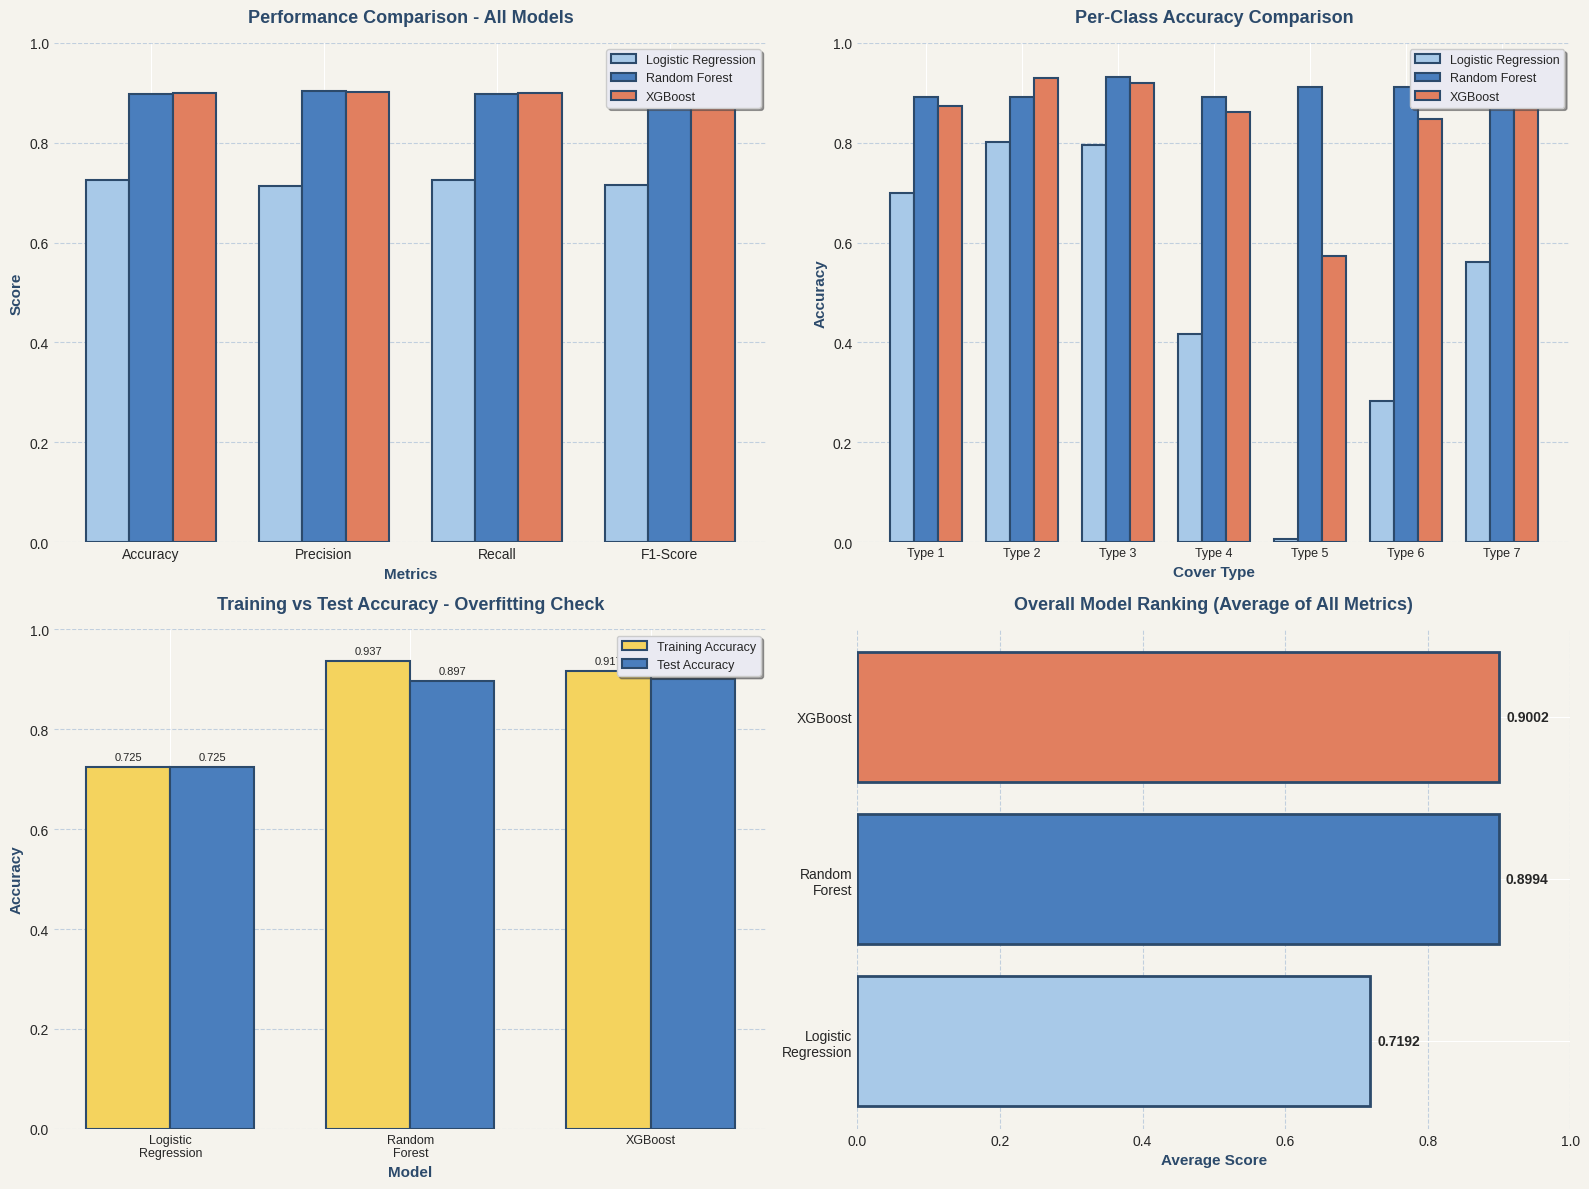


Side-by-Side Confusion Matrix Comparison


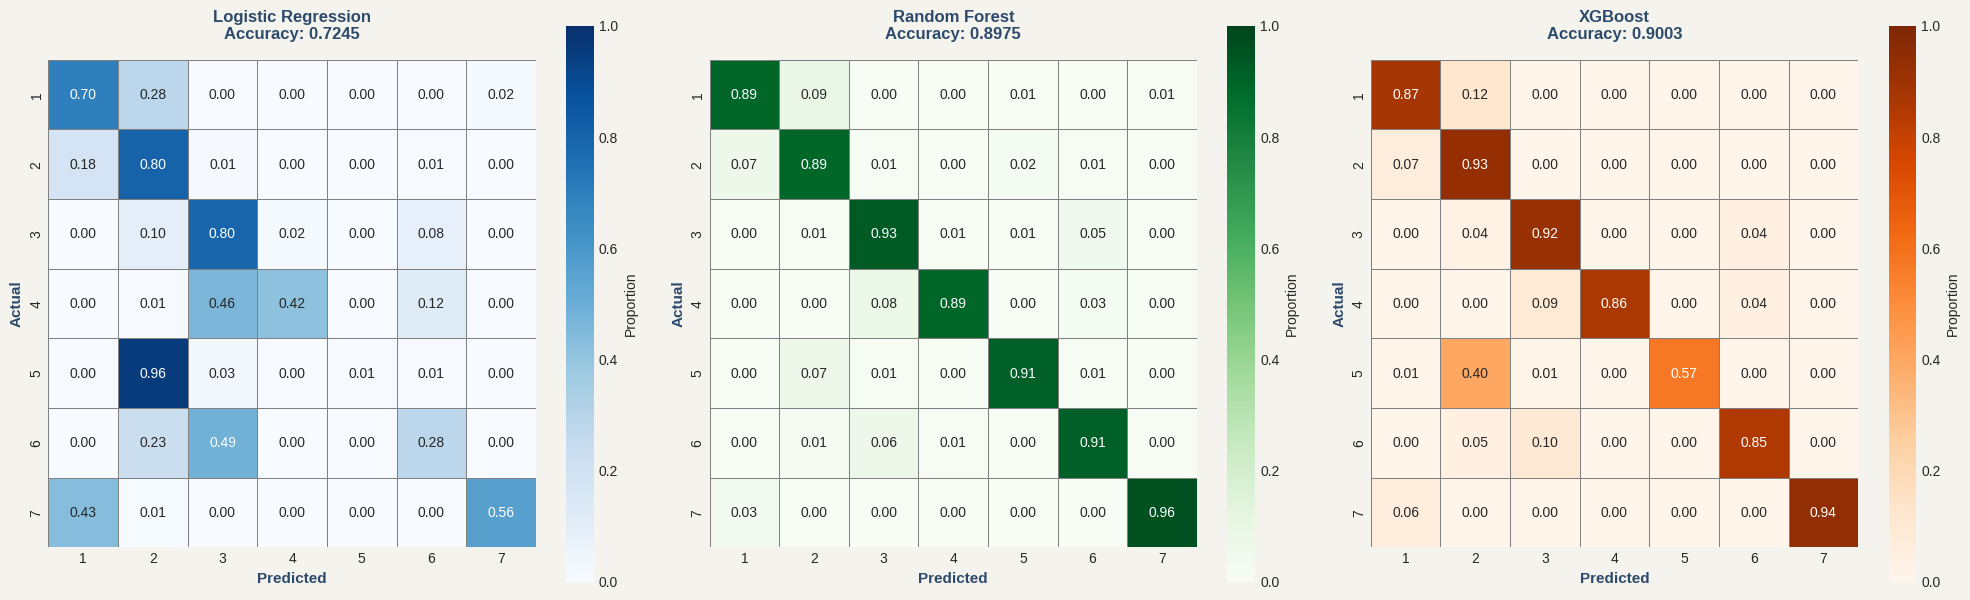


FINAL SUMMARY AND RECOMMENDATIONS

Best Overall Model: XGBoost
   Test Accuracy: 0.9003 (90.03%)

Model Rankings:
   3. XGBoost: 0.9003
   2. Random Forest: 0.8975
   1. Logistic Regression: 0.7245

Key Insights:
   - Best model improved baseline by: 0.1758 (17.58%)
   - XGBoost outperformed Random Forest
   - Consider: XGBoost's boosting approach works well here

Overfitting Analysis:
   - Logistic Regression: -0.0000
   - Random Forest: 0.0395
   - XGBoost: 0.0166
   - All models generalize well

Recommendations:
   1. Deploy: XGBoost (highest accuracy)
   2. Monitor: Per-class performance, especially minority classes
   3. Consider: Hyperparameter tuning for further improvements
   4. Next steps: Cross-validation, ensemble methods, feature engineering


In [50]:
# Custom color palette
primary_color = '#2C4A6B'
secondary_color = '#4A7EBD'
accent_color = '#F4D35E'
bg_color = '#F5F3ED'

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print("\nComprehensive Performance Comparison")

comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [test_accuracy, test_accuracy_rf, test_accuracy_xgb],
    'Precision': [test_precision, test_precision_rf, test_precision_xgb],
    'Recall': [test_recall, test_recall_rf, test_recall_xgb],
    'F1-Score': [test_f1, test_f1_rf, test_f1_xgb],
    'Training Time (s)': [training_time, training_time, training_time]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Find best model for each metric
print("\n   Best Models by Metric:")
print(f"      Accuracy:  {comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']} ({comparison_df['Accuracy'].max():.4f})")
print(f"      Precision: {comparison_df.loc[comparison_df['Precision'].idxmax(), 'Model']} ({comparison_df['Precision'].max():.4f})")
print(f"      Recall:    {comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']} ({comparison_df['Recall'].max():.4f})")
print(f"      F1-Score:  {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']} ({comparison_df['F1-Score'].max():.4f})")

print("\nGenerating Comprehensive Visualizations")

# Calculate per-class accuracies for all models
cm_normalized = confusion_matrix(y_test, y_test_pred, normalize='true')
cm_rf_normalized = confusion_matrix(y_test, y_test_pred_rf, normalize='true')
cm_xgb_normalized = confusion_matrix(y_test, y_test_pred_xgb, normalize='true')

per_class_accuracy = cm_normalized.diagonal()
per_class_accuracy_rf = cm_rf_normalized.diagonal()
per_class_accuracy_xgb = cm_xgb_normalized.diagonal()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor(bg_color)

# Subplot 1: All metrics comparison
ax1 = axes[0, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

bars1 = ax1.bar(x - width, [test_accuracy, test_precision, test_recall, test_f1],
                width, label='Logistic Regression', color='#A8C9E8',
                edgecolor=primary_color, linewidth=1.5)
bars2 = ax1.bar(x, [test_accuracy_rf, test_precision_rf, test_recall_rf, test_f1_rf],
                width, label='Random Forest', color='#4A7EBD',
                edgecolor=primary_color, linewidth=1.5)
bars3 = ax1.bar(x + width, [test_accuracy_xgb, test_precision_xgb, test_recall_xgb, test_f1_xgb],
                width, label='XGBoost', color='#E17F5F',
                edgecolor=primary_color, linewidth=1.5)

ax1.set_xlabel('Metrics', fontsize=11, fontweight='bold', color=primary_color)
ax1.set_ylabel('Score', fontsize=11, fontweight='bold', color=primary_color)
ax1.set_title('Performance Comparison - All Models',
              fontsize=13, fontweight='bold', color=primary_color, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=10)
ax1.legend(loc='upper right', fontsize=9, frameon=True, fancybox=True, shadow=True)
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3, linestyle='--', color=secondary_color)
ax1.set_facecolor(bg_color)

# Subplot 2: Per-class accuracy comparison
ax2 = axes[0, 1]
class_types = [f'Type {i}' for i in range(1, 8)]
x2 = np.arange(len(class_types))

bars1 = ax2.bar(x2 - width, per_class_accuracy, width, label='Logistic Regression',
                color='#A8C9E8', edgecolor=primary_color, linewidth=1.5)
bars2 = ax2.bar(x2, per_class_accuracy_rf, width, label='Random Forest',
                color='#4A7EBD', edgecolor=primary_color, linewidth=1.5)
bars3 = ax2.bar(x2 + width, per_class_accuracy_xgb, width, label='XGBoost',
                color='#E17F5F', edgecolor=primary_color, linewidth=1.5)

ax2.set_xlabel('Cover Type', fontsize=11, fontweight='bold', color=primary_color)
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold', color=primary_color)
ax2.set_title('Per-Class Accuracy Comparison',
              fontsize=13, fontweight='bold', color=primary_color, pad=15)
ax2.set_xticks(x2)
ax2.set_xticklabels(class_types, fontsize=9)
ax2.legend(loc='upper right', fontsize=9, frameon=True, fancybox=True, shadow=True)
ax2.set_ylim([0, 1.0])
ax2.grid(axis='y', alpha=0.3, linestyle='--', color=secondary_color)
ax2.set_facecolor(bg_color)

# Subplot 3: Training vs Test Accuracy
ax3 = axes[1, 0]
models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
train_scores = [train_accuracy, train_accuracy_rf, train_accuracy_xgb]
test_scores = [test_accuracy, test_accuracy_rf, test_accuracy_xgb]
x3 = np.arange(len(models))
width3 = 0.35

bars1 = ax3.bar(x3 - width3/2, train_scores, width3, label='Training Accuracy',
                color='#F4D35E', edgecolor=primary_color, linewidth=1.5)
bars2 = ax3.bar(x3 + width3/2, test_scores, width3, label='Test Accuracy',
                color='#4A7EBD', edgecolor=primary_color, linewidth=1.5)

ax3.set_xlabel('Model', fontsize=11, fontweight='bold', color=primary_color)
ax3.set_ylabel('Accuracy', fontsize=11, fontweight='bold', color=primary_color)
ax3.set_title('Training vs Test Accuracy - Overfitting Check',
              fontsize=13, fontweight='bold', color=primary_color, pad=15)
ax3.set_xticks(x3)
ax3.set_xticklabels(models, fontsize=9)
ax3.legend(loc='upper right', fontsize=9, frameon=True, fancybox=True, shadow=True)
ax3.set_ylim([0, 1.0])
ax3.grid(axis='y', alpha=0.3, linestyle='--', color=secondary_color)
ax3.set_facecolor(bg_color)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Subplot 4: Model Ranking
ax4 = axes[1, 1]
model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
overall_scores = [
    np.mean([test_accuracy, test_precision, test_recall, test_f1]),
    np.mean([test_accuracy_rf, test_precision_rf, test_recall_rf, test_f1_rf]),
    np.mean([test_accuracy_xgb, test_precision_xgb, test_recall_xgb, test_f1_xgb])
]

colors_rank = ['#A8C9E8', '#4A7EBD', '#E17F5F']
bars = ax4.barh(model_names, overall_scores, color=colors_rank,
                edgecolor=primary_color, linewidth=2)

ax4.set_xlabel('Average Score', fontsize=11, fontweight='bold', color=primary_color)
ax4.set_title('Overall Model Ranking (Average of All Metrics)',
              fontsize=13, fontweight='bold', color=primary_color, pad=15)
ax4.set_xlim([0, 1.0])
ax4.grid(axis='x', alpha=0.3, linestyle='--', color=secondary_color)
ax4.set_facecolor(bg_color)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax4.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
            f'{width:.4f}', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

print("\nSide-by-Side Confusion Matrix Comparison")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor(bg_color)

# Logistic Regression
ax1 = axes[0]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', square=True,
            xticklabels=range(1, 8), yticklabels=range(1, 8),
            cbar_kws={'label': 'Proportion'}, ax=ax1, linewidths=0.5,
            linecolor='gray', vmin=0, vmax=1)
ax1.set_xlabel('Predicted', fontsize=11, fontweight='bold', color=primary_color)
ax1.set_ylabel('Actual', fontsize=11, fontweight='bold', color=primary_color)
ax1.set_title(f'Logistic Regression\nAccuracy: {test_accuracy:.4f}',
              fontsize=12, fontweight='bold', color=primary_color, pad=15)
ax1.set_facecolor(bg_color)

# Random Forest
ax2 = axes[1]
sns.heatmap(cm_rf_normalized, annot=True, fmt='.2f', cmap='Greens', square=True,
            xticklabels=range(1, 8), yticklabels=range(1, 8),
            cbar_kws={'label': 'Proportion'}, ax=ax2, linewidths=0.5,
            linecolor='gray', vmin=0, vmax=1)
ax2.set_xlabel('Predicted', fontsize=11, fontweight='bold', color=primary_color)
ax2.set_ylabel('Actual', fontsize=11, fontweight='bold', color=primary_color)
ax2.set_title(f'Random Forest\nAccuracy: {test_accuracy_rf:.4f}',
              fontsize=12, fontweight='bold', color=primary_color, pad=15)
ax2.set_facecolor(bg_color)

# XGBoost
ax3 = axes[2]
sns.heatmap(cm_xgb_normalized, annot=True, fmt='.2f', cmap='Oranges', square=True,
            xticklabels=range(1, 8), yticklabels=range(1, 8),
            cbar_kws={'label': 'Proportion'}, ax=ax3, linewidths=0.5,
            linecolor='gray', vmin=0, vmax=1)
ax3.set_xlabel('Predicted', fontsize=11, fontweight='bold', color=primary_color)
ax3.set_ylabel('Actual', fontsize=11, fontweight='bold', color=primary_color)
ax3.set_title(f'XGBoost\nAccuracy: {test_accuracy_xgb:.4f}',
              fontsize=12, fontweight='bold', color=primary_color, pad=15)
ax3.set_facecolor(bg_color)

plt.tight_layout()
plt.savefig('confusion_matrix_all_models.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

print("\n" + "=" * 70)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("=" * 70)

best_model_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_accuracy = comparison_df.loc[best_model_idx, 'Accuracy']

print(f"\nBest Overall Model: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

print("\nModel Rankings:")
for i, row in comparison_df.sort_values('Accuracy', ascending=False).iterrows():
    print(f"   {i+1}. {row['Model']}: {row['Accuracy']:.4f}")

print("\nKey Insights:")
accuracy_improvement = test_accuracy_xgb - test_accuracy
print(f"   - Best model improved baseline by: {accuracy_improvement:.4f} ({accuracy_improvement*100:.2f}%)")

if test_accuracy_rf > test_accuracy_xgb:
    print("   - Random Forest outperformed XGBoost")
    print("   - Consider: RF might be better for this specific dataset")
elif test_accuracy_xgb > test_accuracy_rf:
    print("   - XGBoost outperformed Random Forest")
    print("   - Consider: XGBoost's boosting approach works well here")
else:
    print("   - Random Forest and XGBoost performed similarly")

overfitting_lr = train_accuracy - test_accuracy
overfitting_rf = train_accuracy_rf - test_accuracy_rf
overfitting_xgb = train_accuracy_xgb - test_accuracy_xgb

print(f"\nOverfitting Analysis:")
print(f"   - Logistic Regression: {overfitting_lr:.4f}")
print(f"   - Random Forest: {overfitting_rf:.4f}")
print(f"   - XGBoost: {overfitting_xgb:.4f}")

if overfitting_rf < 0.05 and overfitting_xgb < 0.05:
    print("   - All models generalize well")
else:
    print("   - Consider regularization or hyperparameter tuning")

print("\nRecommendations:")
print(f"   1. Deploy: {best_model_name} (highest accuracy)")
print("   2. Monitor: Per-class performance, especially minority classes")
print("   3. Consider: Hyperparameter tuning for further improvements")
print("   4. Next steps: Cross-validation, ensemble methods, feature engineering")